In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision.models import densenet121
import numpy as np
import torch.nn.functional as F
from torch.utils.data import Dataset
from tqdm import tqdm

In [2]:
torch.cuda.is_available()

True

In [3]:
import h5py

with h5py.File('Data/data.mat', 'r') as f:
    print(list(f.keys()))  # see variables inside
    
    # example: load a dataset
    N = f['N'][:]
    img_truth = f['img'][:]
    total_freq_power = f['total_freq_power'][:]
    # total_lambda = f['total_lambda'][:] #not needed
    total_recon = f['total_recon'][:]
    total_residual = f['total_residual'][:]
print(total_freq_power.shape)
print(total_recon.shape)
print(total_residual.shape)

['N', 'img', 'total_freq_power', 'total_lambda', 'total_recon', 'total_residual']
(171900, 64, 64)
(171900, 64, 64)
(171900, 64, 64)


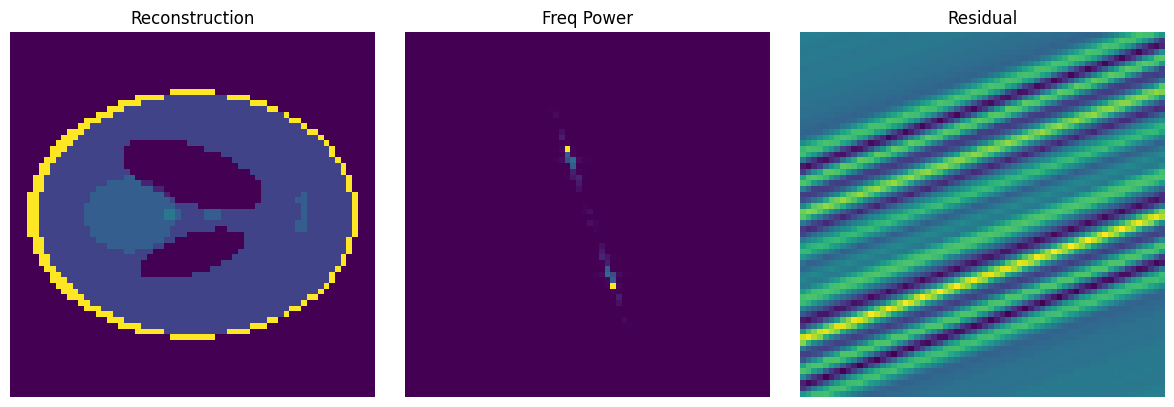

In [4]:
# verifying data import
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(total_recon[-1, :, :])
axes[0].set_title("Reconstruction")
axes[0].axis("off")

axes[1].imshow(total_freq_power[-1, :, :])
axes[1].set_title("Freq Power")
axes[1].axis("off")

axes[2].imshow(total_residual[-1, :, :])
axes[2].set_title("Residual")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [5]:
from recon_dataset import ReconDataset
from torch.utils.data import DataLoader
        
dataset = ReconDataset(
    total_recon,
    total_residual,
    total_freq_power,
    img_truth
)

loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)       

In [6]:
# use this for current reconstruction img
class DenseNetBackbone(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()

        model = densenet121(pretrained=pretrained)

        # remove classifier
        self.features = model.features

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        x = self.features(x)     # (B, C, H, W)
        x = nn.functional.relu(x, inplace=True)
        x = self.pool(x)        # (B, C, 1, 1)
        return x.view(x.size(0), -1)
# this output is of size (BATCH, 1024)

In [7]:
# use this for the residual
class Residual1DCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

    def forward(self, x):
        # x: (B, 64, 64) → pick projection axis
        x = x.mean(dim=1)  # or select projection direction
        x = x.unsqueeze(1)  # (B, 1, 64)
        return self.net(x).squeeze(-1)
# this output is of size (BATCH,64)

In [8]:
# use this for FT domain of the residual
class FFT2DCNN(nn.Module):
    def __init__(self, base=32):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, base, 3, padding=1),
            nn.BatchNorm2d(base),
            nn.ReLU(),

            nn.Conv2d(base, base*2, 3, padding=1),
            nn.BatchNorm2d(base*2),
            nn.ReLU(),

            nn.Conv2d(base*2, base*2, 3, padding=1),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        x = torch.log1p(torch.abs(x))   # IMPORTANT for FFT stability
        x = self.net(x)
        x = self.pool(x)
        return x.view(x.size(0), -1)
# this output is of size (BATCH,64)

In [9]:
# fusion model
class FusionModule(nn.Module):
    def __init__(self, d1=1024, d2=64, d3=64, d=128, hidden=256, out_dim=128):
        super().__init__()

        # --- modality projection ---
        self.refine1 = nn.Linear(d1, d)
        # self.refine2 = nn.Linear(d2, d)
        self.refine2 = nn.Linear(d1, d)
        self.refine3 = nn.Linear(d3, d)

        # --- gating network ---
        self.gate = nn.Sequential(
            nn.Linear(3 * d, 64),
            nn.ReLU(),
            nn.Linear(64, 3),
            nn.Softmax(dim=1)
        )

        # --- joint representation ---
        self.fc = nn.Sequential(
            nn.Linear(3 * d, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU()
        )

        # --- final embedding ---
        self.out = nn.Linear(hidden + d, out_dim)

    def forward(self, f1, f2, f3):

        # 1. project to shared space
        f1 = self.refine1(f1)  # (B,128)
        f2 = self.refine2(f2)  # (B,128)
        f3 = self.refine3(f3)  # (B,128)

        # 2. concatenate
        x = torch.cat([f1, f2, f3], dim=1)  # (B,384)

        # 3. gating weights
        w = self.gate(x)  # (B,3)

        # 4. weighted fusion
        fused = (
            w[:, 0:1] * f1 +
            w[:, 1:2] * f2 +
            w[:, 2:3] * f3
        )  # (B,128)

        # 5. joint nonlinear embedding
        h = self.fc(x)  # (B,256)

        # 6. final embedding
        out = self.out(torch.cat([h, fused], dim=1))  # (B,128)

        return out

In [10]:
class MultiModalNet(nn.Module):
    def __init__(self, K=5):
        super().__init__()

        self.K = K

        self.img_branch = DenseNetBackbone()
        self.res_branch = DenseNetBackbone() # Residual1DCNN()
        self.fft_branch = FFT2DCNN()

        self.fusion = FusionModule(
            d1=1024,
            d2=1024, #64,
            d3=64,
            d=128,
            hidden=256,
            out_dim=128
        )

        self.regressor = nn.Linear(128, 1)

    def forward(self, x_img, x_res_init, x_fft, x_truth):

        x = x_img
        x_res = x_res_init

        loss = 0.0

        # store initial residual norm (for convergence pressure)
        r0 = torch.mean((x_truth - x_img) ** 2)

        for _ in range(self.K):

            # compute current residual in image space
            r_img = x_truth - x

            # optionally map residual into your provided residual domain
            x_res = x_res_init  # or recompute if dynamic

            # feature extraction
            # f1 = self.img_branch(x)
            f1 = self.img_branch(x.repeat(1, 3, 1, 1))
            # f2 = self.res_branch(x_res)
            f2 = self.res_branch(x_res.repeat(1, 3, 1, 1))
            f3 = self.fft_branch(x_fft)

            fused = self.fusion(f1, f2, f3)

            lam = self.regressor(fused)

            # bound lambda
            lam = torch.sigmoid(lam)
            lam = 1e-4 + (2.0 - 1e-4) * lam
            lam = lam.view(-1, 1, 1, 1)

            # update step
            x = x + lam * x_res

            # reconstruction loss (trajectory supervision)
            loss = loss + F.mse_loss(x, x_truth)

            # convergence pressure (residual decay)
            r = torch.mean((x_truth - x) ** 2)
            loss = loss + 0.1 * (r / (r0 + 1e-8))

        return loss, x, lam

In [11]:
# device = torch.device("cpu")
# device = torch.device("mps")
device = torch.device("cuda")

In [ ]:
model = MultiModalNet(K=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 10
print_every = 50  # batches

for epoch in range(EPOCHS):
    running_loss = 0.0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for i, (x_img, x_res, x_fft, x_truth) in enumerate(pbar):
        # x_img = x_img.to(device).repeat(1, 3, 1, 1)
        x_img = x_img.to(device)
        x_res = x_res.to(device)
        x_fft = x_fft.to(device)
        x_truth = x_truth.to(device)

        x = x_img
        loss = 0

        for k in range(model.K):
            loss_k, x, lam = model(x, x_res, x_fft, x_truth)
            loss += loss_k

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # update progress bar live
        pbar.set_postfix(loss=loss.item())

        if i % print_every == 0:
            print(f"\nBatch [{i}/{len(loader)}] Loss: {loss.item():.6f}")

    print(f"===> Epoch {epoch+1} Complete | Avg Loss: {running_loss/len(loader):.6f}")

C:\Users\clin4\.conda\envs\torch\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\clin4\.conda\envs\torch\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/10:   0%|                                                      | 1/10744 [00:02<7:20:45,  2.46s/it, loss=0.881]


Batch [0/10744] Loss: 0.880882


Epoch 1/10:   0%|                                                     | 11/10744 [00:14<3:37:59,  1.22s/it, loss=0.897]